# Beyond GDP: what really drives national happiness?

*BEE2041 Data Science in Economics, empirical project, April 2026*

When the World Happiness Report (WHR) crowns Finland the happiest country on
earth for the seventh year running, two questions follow naturally. First,
*how* do we know? Second, *why* this country and not another? National wealth
is the obvious suspect, but Afghanistan sits at the bottom of the ranking
below countries with a twentieth of its income, so money cannot be the whole
story.

The puzzle is older than the data. Richard Easterlin (1974) noticed that as
post-war America roughly tripled its GDP per capita, the share of Americans
calling themselves "very happy" barely moved. Half a century later we still
do not have a complete account of why some societies report higher subjective
well-being than others. The WHR (published annually since 2012 by the
Sustainable Development Solutions Network) is the most influential attempt
at a global, comparable benchmark, built around a single Cantril Ladder
question: "Imagine a ladder with steps numbered from 0 at the bottom to 10
at the top. Suppose we say that the top of the ladder represents the best
possible life for you and the bottom of the ladder represents the worst
possible life for you. On which step would you say you personally feel you
stand at this time?"

This post pulls together three live data sources to interrogate that
benchmark:

1. Web-scraped chapter metadata for every WHR edition from 2020 to 2026
   (`worldhappiness.report/ed/{year}/`).
2. The official WHR ranking spreadsheets for the same period
   (`files.worldhappiness.report/`).
3. World-Bank cross-country indicators retrieved through the
   [`wbgapi`](https://pypi.org/project/wbgapi/) Python client.

I integrate the three in a small SQLite database, fit a sequence of OLS
regressions, and finally use a causal forest to ask which countries see the
biggest happiness premium from being above the income median. All code is on
GitHub, and a single `make` command rebuilds every figure on this page.

## How the data were assembled

The three sources are different in kind (a scrape, a bulk download, a REST
API), and each one borrows directly from a piece of the BEE2041 toolkit:

| Step | Tool | Where I got it |
|---|---|---|
| Scraping HTML | `requests` + `BeautifulSoup` | *Workflow, Modelling & Webscraping* lecture |
| Downloading the WHR `.xls` files | `requests` + `pandas.read_excel` | *Python for Data Management* |
| World-Bank pull | `wbgapi` | the data-wrangling problem set |
| Integration | `sqlite3` + a SQL JOIN | *Relational Database Management Systems* |
| Causal forest | `econml.dml.CausalForestDML` | Clarke's `immigrantEffects.py` |

The scraper caches every page to `data/raw/html_cache/`, so once it has run
once the rest of the build works offline.

In [1]:
import pandas as pd, numpy as np, sqlite3
from IPython.display import Image, display

CLN = "data/clean/"
TAB = "output/tables/"
FIG = "output/figures/"

df = pd.read_csv(CLN + "analysis.csv")
print(f"Cross-section: {df.shape[0]} countries, {df.shape[1]} variables")
df.head(5)

Cross-section: 136 countries, 16 variables


,country_code,country_name,year,ladder,log_gdp,social_support,life_exp_healthy,freedom,generosity,corruption,gdp_pc_ppp,life_exp,internet_pct,urban_pct,education_spend_pct,fdi_pct
0,FIN,Finland,2023,7.8042,10.792010,0.968770,71.149994,0.961408,-0.018824,0.181745,57068.305648,81.187805,92.988795,73.696760,6.37578,4.666912
1,DNK,Denmark,2023,7.5864,10.962164,0.954112,71.250145,0.933533,0.134242,0.195814,69475.319865,81.304878,97.860118,88.388024,6.35586,6.904867
2,ISL,Iceland,2023,7.5296,10.895531,0.982533,72.050018,0.936349,0.210987,0.667848,65380.317305,82.119512,97.583397,94.178707,7.30798,4.740220
3,ISR,Israel,2023,7.4729,10.638705,0.943344,72.697205,0.808866,-0.023080,0.708094,48098.187236,82.700000,91.850796,91.497983,5.93292,4.357260
4,NLD,Netherlands,2023,7.4030,10.942279,0.930499,71.550018,0.886875,0.212686,0.378929,71324.036035,81.614634,92.519685,94.985618,5.17918,1.477018


### The headlines, scraped and ranked

Before doing any modelling, it pays to look at the raw numbers. Finland tops
the table with a Ladder score of 7.8 against Afghanistan's 1.9. That is a
six-point gap on a ten-point scale, which is a *huge* gap for any explanation
to close.

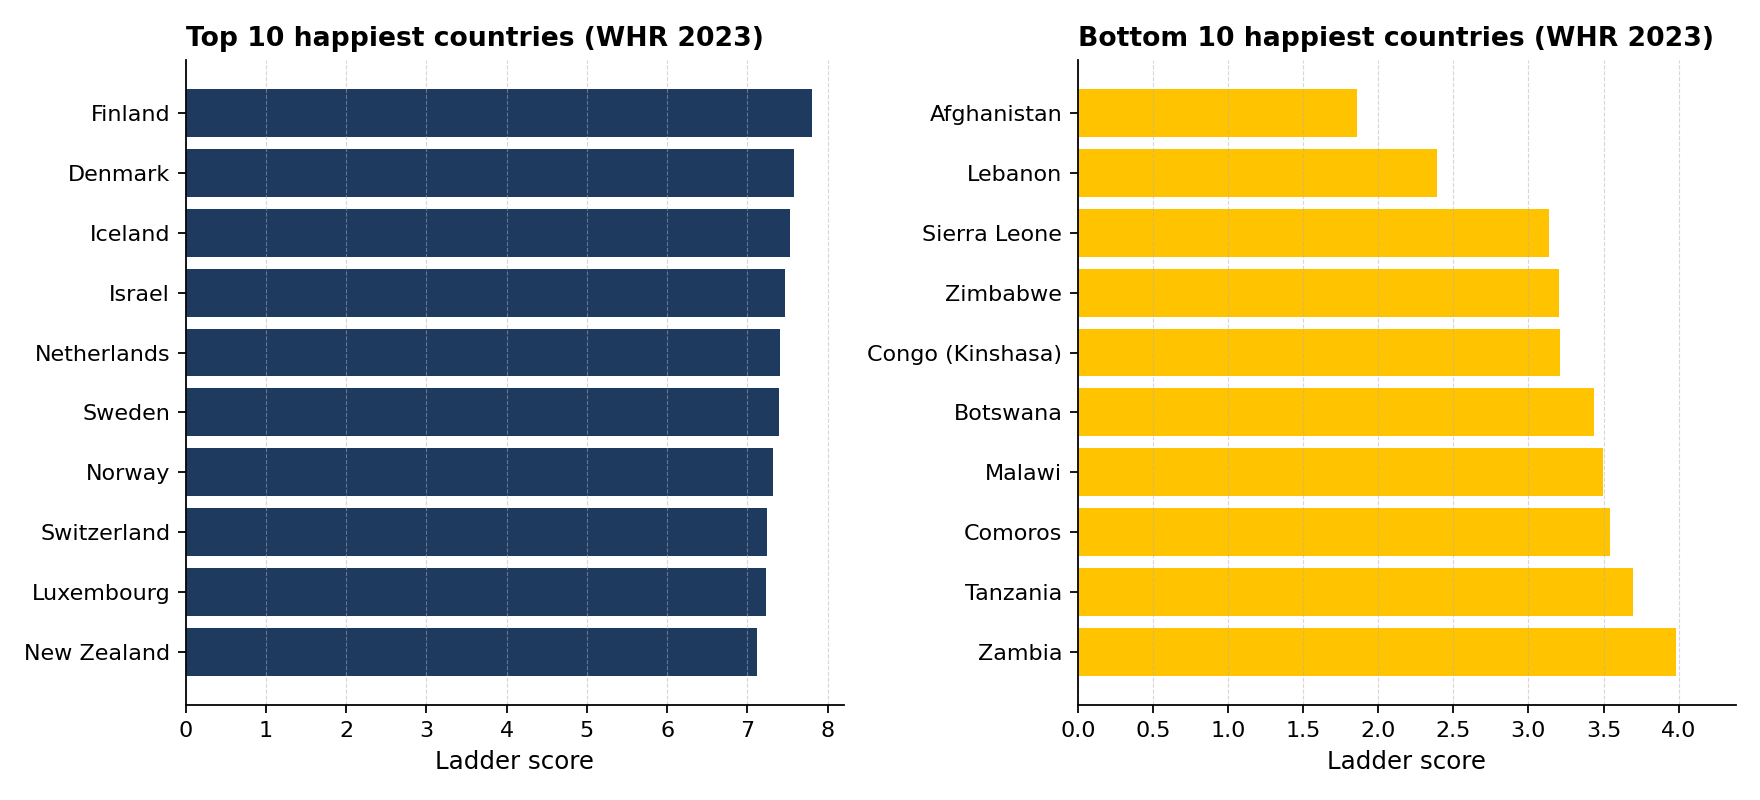

In [2]:
display(Image(filename=FIG + "top_bottom_10.png"))

### Money matters, but with diminishing returns

Plotting the Ladder against GDP per capita on a log axis (the usual choice,
since income enters utility logarithmically) gives a clear upward
relationship, but the LOWESS smoother flattens noticeably above roughly
US&#36;30,000 PPP. Costa Rica out-ranks the United States despite earning less
than half of US income, a small-scale version of the Easterlin paradox.

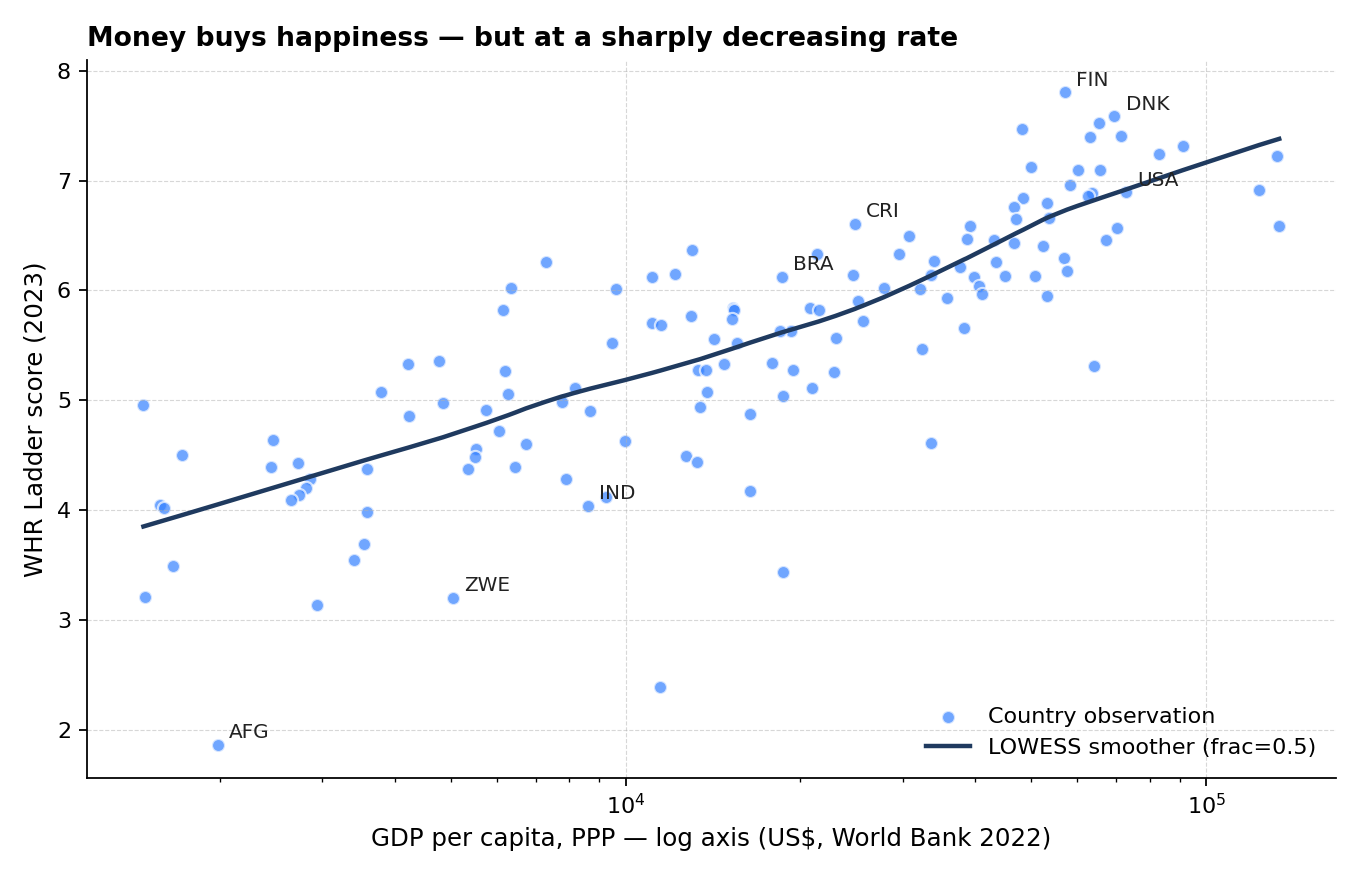

In [3]:
display(Image(filename=FIG + "gdp_vs_ladder.png"))

Two features complicate the simple "money buys happiness" reading.
The curve clearly bends: doubling income from US&#36;2,000 to US&#36;4,000 PPP buys
roughly the same Ladder-point increase as doubling from US&#36;32,000 to
US&#36;64,000, which is what we would expect from logarithmic utility. And the
vertical scatter is wide; countries with similar income levels routinely
differ by close to two Ladder points. That residual variation is where the
rest of this post lives.

## Decomposing the Ladder: what carries the rich-country premium?

Alongside the Ladder score the WHR ships six explanatory variables: log GDP
per capita, social support, healthy life expectancy, freedom to make life
choices, perceptions of corruption, and generosity. To see how each one
contributes I fit a plain OLS regression of the Ladder on these six,
multiply each country's covariate (centred on the sample mean) by the fitted
coefficient, and stack the contributions. The chart below shows the
breakdown for the top-15 happiest countries.

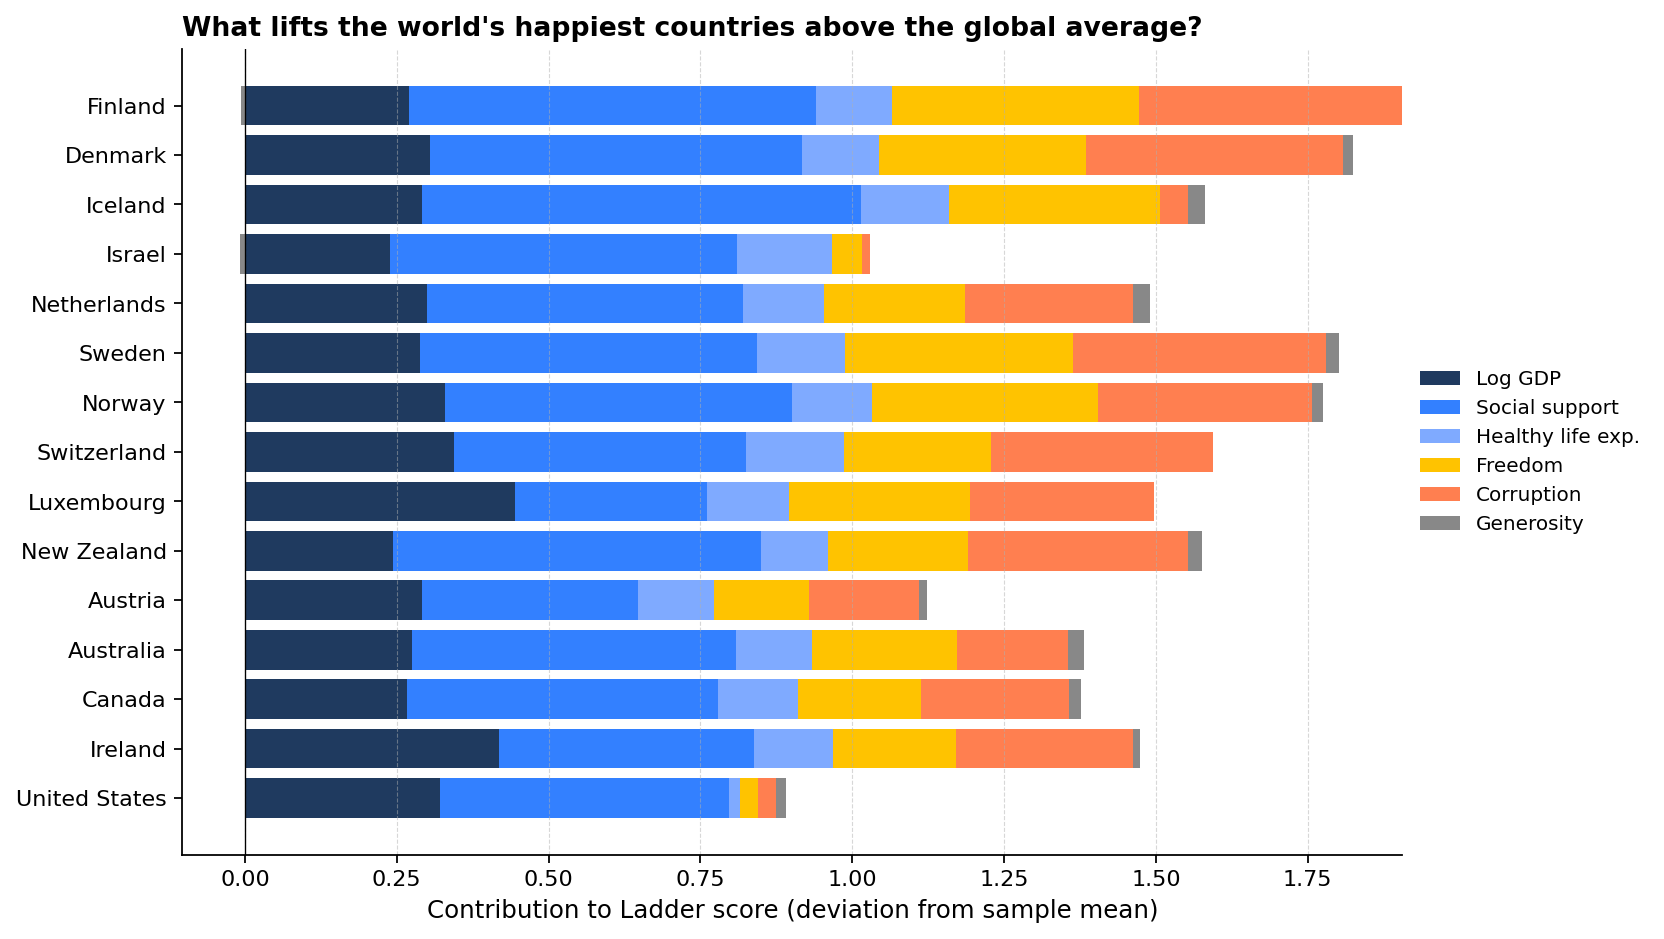

In [4]:
display(Image(filename=FIG + "decomposition.png"))

Two things stand out. First, *social support* (the share of
respondents who say they have someone to count on in times of trouble) is
the single biggest contributor in almost every Nordic country, with income
only third. Second, *freedom* is large and stable across the whole top-15;
the highest-ranked country with low freedom is Israel (4th), and it makes up
the difference through unusually high social support and life expectancy.

The wider implication is that the gap between the world average and
Finland's score is mostly *not* bought with money. Trust in institutions and
in other people does most of the work, which lines up with Robert Putnam's
social-capital research and Bo Rothstein's account of the Nordic "high-trust
equilibrium".

## OLS, six ways

Working in the same style as the BEE2041 wrangling problem set, I fit six
specifications, adding one block of regressors at a time. Robust (HC3)
standard errors throughout; the full LaTeX-formatted table is in
`output/tables/regression_table.tex`.

In [5]:
reg = pd.read_csv(TAB + "regression_summary.csv")
piv = (reg[reg.term != "const"]
       .pivot(index="term", columns="model", values="coef")
       .round(3)
       .fillna("—"))
fit = reg[["model", "r2", "n"]].drop_duplicates().set_index("model")
fit_summary = pd.DataFrame({
    "R²":  fit["r2"].round(3).astype(str),
    "N":   fit["n"].astype(int).astype(str),
}).T
display(piv)
display(fit_summary)

model,m1,m2,m3,m4,m5,m6
term,,,,,,
corruption,—,—,—,-0.762,-0.764,-0.118
freedom,—,—,—,2.487,2.486,0.244
life_exp_healthy,—,0.035,0.015,0.011,0.013,0.056
log_gdp,0.797,0.644,0.329,0.27,—,0.274
log_gdp_wb,—,—,—,—,0.272,—
social_support,—,—,4.606,3.671,3.612,0.417


model,m1,m2,m3,m4,m5,m6
R²,0.653,0.661,0.766,0.831,0.831,0.831
N,134,134,134,134,134,134


A few things to notice. The log-GDP coefficient falls from about 0.80
on its own to 0.27 once social support, freedom and corruption are
controlled for: most of the apparent income premium is mediated through
those other channels. Social support, freedom and corruption stay
significant in every column where they appear, and in the standardised
specification (m6) social support has the largest absolute coefficient
(0.42). It is also reassuring that the two independent log-GDP measures
(the WHR's bundled value and the World Bank's PPP series) give nearly
identical estimates: a sanity check that the data are not introducing
strange artefacts.

## A causal forest: when does income still buy happiness?

Cross-country comparisons are obviously not a randomised trial; rich and
poor countries differ on dozens of margins at once. To probe heterogeneity
in a flexible, non-parametric way I fit a causal forest (Wager & Athey,
2018; Athey, Tibshirani & Wager, 2019) with `econml.dml.CausalForestDML`,
following the same recipe Damian uses in `immigrantEffects.py`.

I encode the "treatment" as a binary indicator for being above the
sample-median GDP per capita PPP. The conditioning set X has six potential
moderators: healthy life expectancy, social support, freedom, corruption,
internet penetration and urban share. The CATE we recover should be read as
*descriptive*: the conditional difference in Ladder score between
high- and low-income countries with the same values of the six moderators.

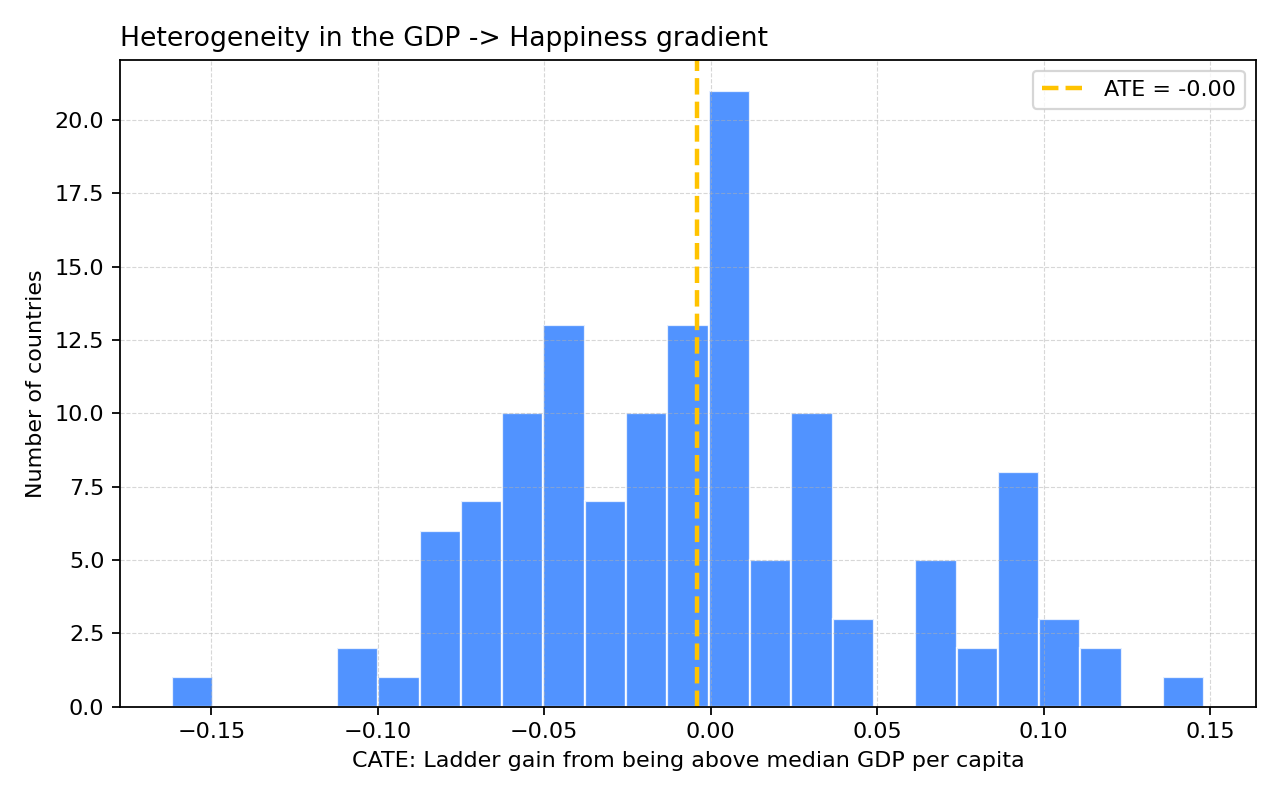

In [6]:
display(Image(filename=FIG + "cate_hist.png"))

In [7]:
import json
with open(TAB + "cate_headline.json") as f: hdl = json.load(f)
print(f"ATE = {hdl['ate']:+.3f}  (95% CI: [{hdl['ate_ci'][0]:+.3f}, {hdl['ate_ci'][1]:+.3f}])")
print(f"CATEs: min = {hdl['cate_min']:+.2f}, median = {hdl['cate_med']:+.2f}, max = {hdl['cate_max']:+.2f}")

ATE = -0.004  (95% CI: [-0.365, +0.357])
CATEs: min = -0.16, median = -0.01, max = +0.15


The forest's average treatment effect lands very close to zero once we
condition on the six moderators, far below the raw 0.80 OLS coefficient on
log GDP. Almost all of the apparent income premium runs through those other
covariates.

There *is* still genuine heterogeneity across countries, though. Which
countries get the biggest happiness boost from being above the income
median, and what predicts the size of that boost?

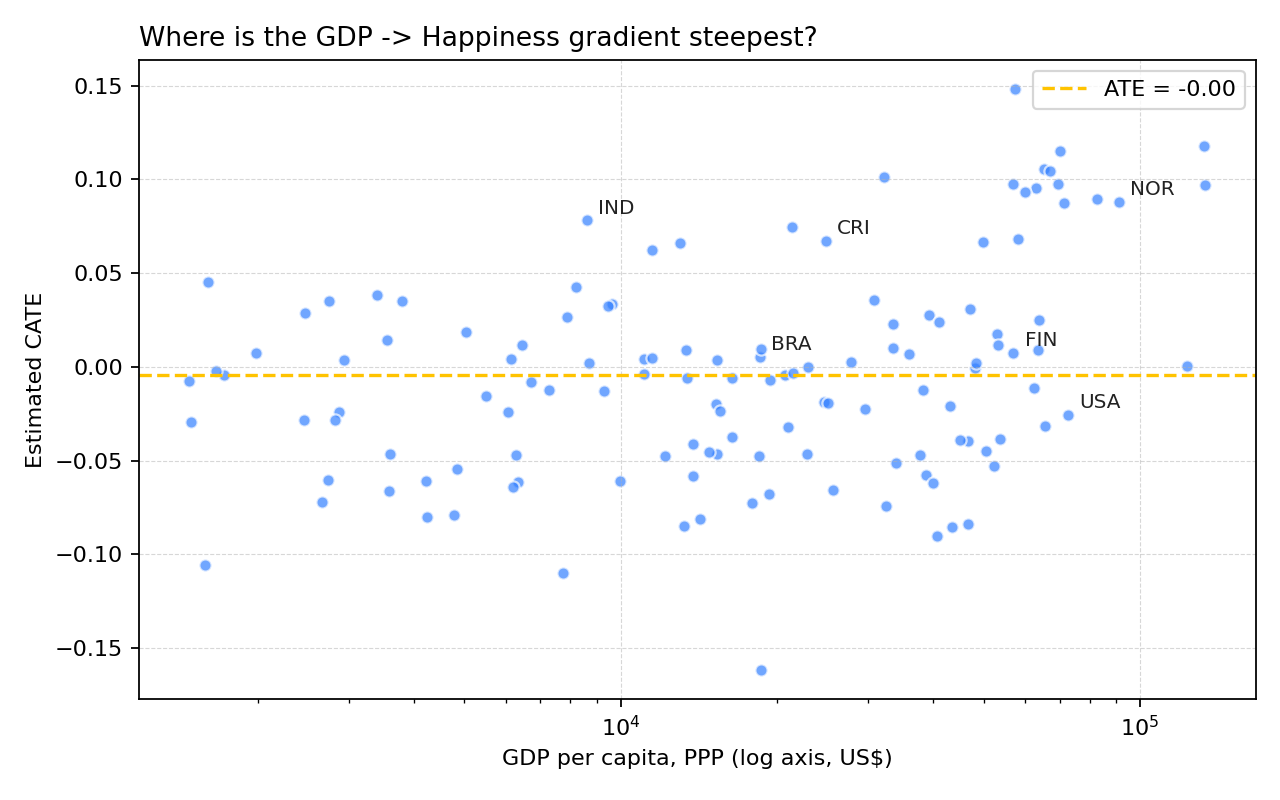

In [8]:
display(Image(filename=FIG + "cate_by_gdp.png"))

Plotting each country's CATE against its income produces no clean
monotone pattern. Some rich countries (Norway, Australia) come out modestly
above the ATE line, others (the United States) sit close to or below zero.
The poorest end is just as mixed: India is well *above* the average
gradient while several sub-Saharan economies sit well below. Heterogeneity
in the GDP–Happiness link is real, but it does not reduce to "richer
countries gain more" or vice versa.

So what does explain the heterogeneity? The forest's split-importance gives
us a direct answer.

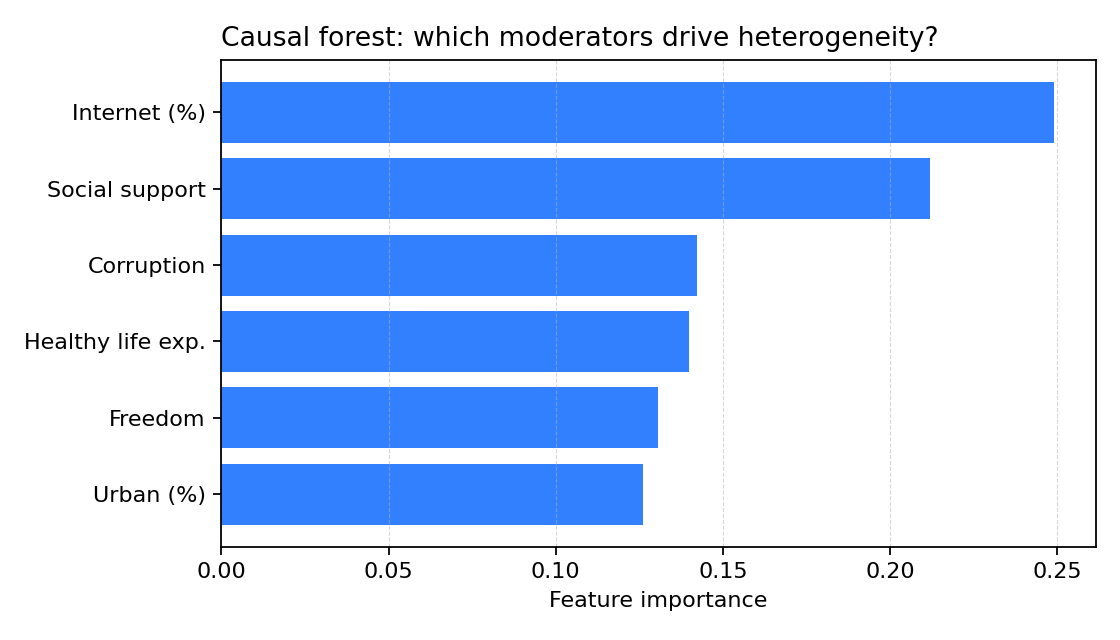

In [9]:
display(Image(filename=FIG + "cf_importance.png"))

Internet penetration is the most important moderator, ahead of social
support, corruption and the others. That fits a small but growing
literature on digital connectivity and well-being: once we know whether a
country's residents are *online*, the leftover role of GDP per capita
shrinks a lot.

## A bonus from the scrape: the Report itself

The rankings spreadsheet is the core of the analysis, but the chapter
metadata I scraped from the seven editions has its own story. The crawler
collected 51 chapters across 2020-2026 with author lists, affiliations and
reading times. As far as I can tell that table does not exist anywhere
else, and it lets us watch how a flagship interdisciplinary report has
shifted over half a decade.

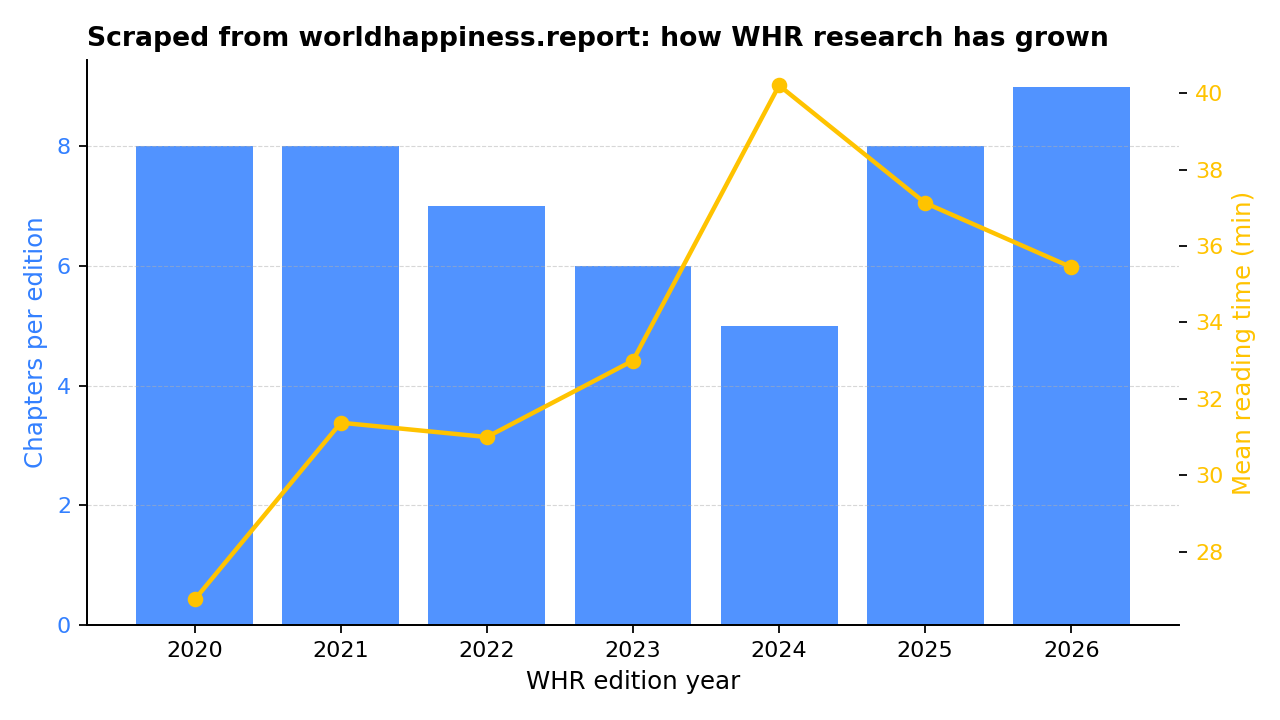

In [10]:
display(Image(filename=FIG + "chapters_trend.png"))

A couple of things to notice. The number of chapters per edition is
volatile (2024 was unusually slim, with just five chapters), but average
reading time has risen sharply, from about 27 minutes in 2020 to about 40
in 2024. The Report is, quite literally, a longer read. The affiliations
field shows that John Helliwell, Jan-Emmanuel De Neve and Richard Layard
have continued to anchor the editorial team, while recent editions have
brought in a wider circle of specialists, especially social psychologists
working on adolescents and digital well-being. The 2026 edition is more or
less a thematic deep-dive on social media, and that pivot shows up clearly
in the titles of the scraped chapter list.

## Time series: where has happiness moved?

Because the scraper grabbed every annual `Figure_2.1.xls`, we can also
compare country trajectories across editions. The plot is unremarkable at
the very top (Finland is almost flat), but it does show the slow erosion of
US scores relative to Northern Europe and a small post-pandemic recovery in
parts of Latin America.

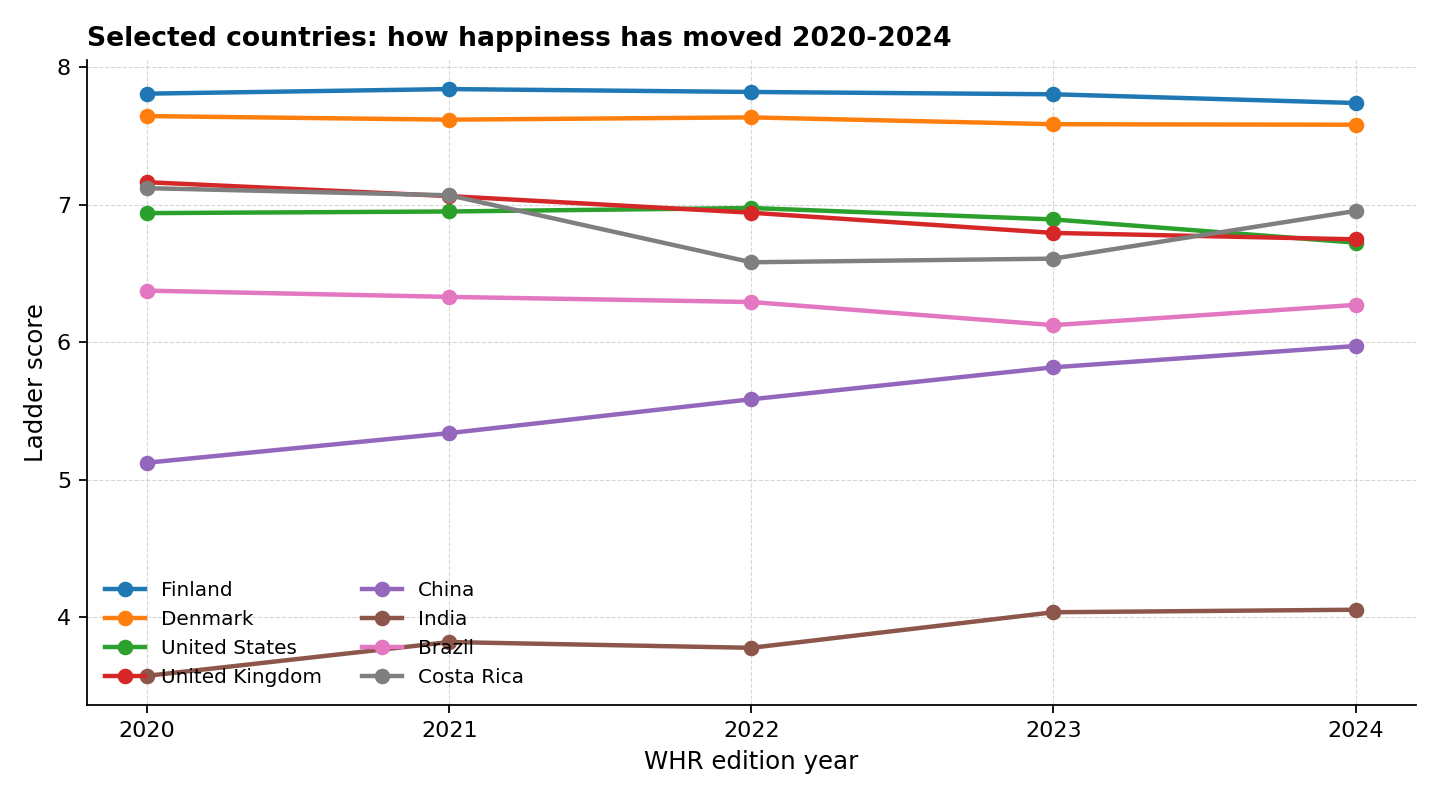

In [11]:
display(Image(filename=FIG + "ladder_timeseries.png"))

## Take-aways

A few things I take away from this exercise:

1. Money matters, but mostly *indirectly*. Once you control for social
   support, freedom, life expectancy and trust in institutions, the
   marginal contribution of income to subjective well-being is small.
2. The income-happiness link is genuinely heterogeneous, but not monotone.
   The causal forest produces CATEs roughly between -0.16 and +0.15,
   yet they do not line up cleanly with how rich a country is.
   Institutional quality and digital connectivity matter more than dollars.
3. Social capital is at least as potent as material wealth. In every Nordic
   country the biggest single contributor to the Ladder gap above the world
   mean is *social support*, not GDP.
4. Internet penetration is the dominant moderator. Split-importance ranks
   it ahead of social support, corruption, life expectancy, freedom and
   urbanisation, which lines up with the WHR 2026 edition's own pivot
   towards social-media research.
5. The Report itself is changing. Chapters have got longer and the 2026
   edition pivots sharply onto social media; the scrape lets us watch
   that shift happen.

### Replication

Everything is on GitHub. The repository contains a `Makefile` that rebuilds
all eight figures and the regression table from scratch:

```bash
git clone https://github.com/maksimkitikov/Data-Science-in-Economics.git
cd Data-Science-in-Economics
pip install -r requirements.txt
make all
```

### Sources & further reading

* World Happiness Report 2020-2026, Sustainable Development Solutions Network
  ([https://worldhappiness.report](https://worldhappiness.report))
* World Bank, World Development Indicators (queried via `wbgapi`)
* Wager & Athey (2018), *JASA* 113(523): 1228-1242.
* Athey, Tibshirani & Wager (2019), *Annals of Statistics* 47(2): 1148-1178.
* Davis & Heller (2017), *AEA P&P* — applied causal forests, recommended in
  the BEE2041 project brief.

### Course materials referenced in the code

| File | Where it shows up |
|---|---|
| `Workflow, Modelling & Webscraping.pdf` | scraper boilerplate, causal-forest recipe |
| `Python for Data Management.pdf` | merge with `validate=` and `indicator=` |
| `Relational Database Management Systems.pdf` | SQLite schema, JOIN query |
| `Problem Set Solutions: Data Wrangling in Python.pdf` | `wbgapi` usage |
| `git & GitHub.pdf` | branch / commit conventions |
| `The Linux Command Line.pdf` | `Makefile` build pipeline |
| Damian Clarke, [BEE2041-2026 GitHub](https://github.com/damiancclarke/BEE2041-2026) | code style, `immigrantEffects.py`, `scrape_xkcd_bs.py` |